In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"D:\Downloads\train (1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
import seaborn as sns 
import matplotlib.pyplot as pl

In [5]:
numeric_cols = ['Age','Fare']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]        

In [6]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [7]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0
6,0,1,0,54.0,0,0,51.8625,0


In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())  

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,0.339415,1,0,0.104618,0
2,1,3,1,0.402328,0,0,0.114358,0
3,1,1,1,0.543882,1,0,0.766234,0
4,0,3,0,0.543882,0,0,0.116162,0
6,0,1,0,0.842718,0,0,0.748377,0


In [14]:
df.shape

(607, 8)

In [15]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['FamilyGroup'] = df['FamilySize'].apply(lambda x: 'Alone' if x == 1 else ('Small' if x <= 4 else 'Large'))
df['FamilyGroup'] = df['FamilyGroup'].map({'Alone': 0, 'Small': 1, 'Large': 2})
df = df.drop(['SibSp', 'Parch'], axis=1)


In [16]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,FamilyGroup
0,0,3,0,0.339415,0.104618,0,2,1
2,1,3,1,0.402328,0.114358,0,1,0
3,1,1,1,0.543882,0.766234,0,2,1
4,0,3,0,0.543882,0.116162,0,1,0
6,0,1,0,0.842718,0.748377,0,1,0


In [17]:
df.isnull().sum()

Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
FamilySize     0
FamilyGroup    0
dtype: int64

In [19]:
df.describe()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,FamilyGroup
count,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000
mean,0.360791,2.433278,0.334432,0.437664,0.273209,0.215815,1.899506,0.469522
std,0.480626,0.734631,0.472180,0.211215,0.204681,0.498725,1.518244,0.630870
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2.000000,0.000000,0.307958,0.114358,0.000000,1.000000,0.000000
50%,0.000000,3.000000,0.000000,0.433784,0.187590,0.000000,1.000000,0.000000
75%,1.000000,3.000000,1.000000,0.559610,0.378788,0.000000,2.000000,1.000000
max,1.000000,3.000000,1.000000,1.000000,1.000000,2.000000,8.000000,2.000000


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X = df.drop(['Survived'],axis=1)
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=45)

In [24]:
from sklearn.linear_model import LogisticRegression

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [36]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)  # should be 0 or 1
print(accuracy_score(y_test, y_pred))


0.8114754098360656


In [41]:
import seaborn as sns 
import matplotlib.pyplot as plt

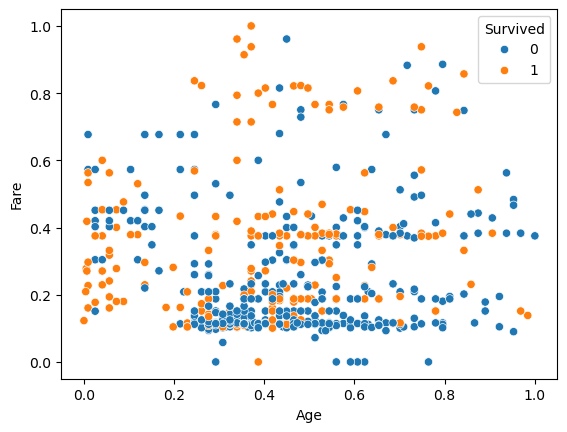

In [45]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')
plt.show()

In [51]:
from sklearn.svm import SVC

In [52]:
svc = SVC()
svc.fit(X_train,y_train)

SVC()

In [53]:
from sklearn.metrics import accuracy_score

y_pred = svc.predict(X_test)  # should be 0 or 1
print(accuracy_score(y_test, y_pred))


0.7704918032786885


In [55]:
from xgboost import XGBClassifier

In [56]:
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [57]:
from sklearn.metrics import accuracy_score

y_pred = xgb.predict(X_test)  # should be 0 or 1
print(accuracy_score(y_test, y_pred))


0.8032786885245902


In [59]:
from sklearn.ensemble  import RandomForestClassifier

In [60]:
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=45
)
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, random_state=45)

In [61]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)  # should be 0 or 1
print(accuracy_score(y_test, y_pred))


0.7950819672131147


In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # only solver that supports l1 + l2
    'max_iter': [100, 200, 500]
}

lr = LogisticRegression()
grid = GridSearchCV(lr, params, cv=5)
grid.fit(X_train, y_train)

print("Best Score:", grid.best_score_)
print("Best Params:", grid.best_params_)


Best Score: 0.7938144329896908
Best Params: {'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}


In [63]:
test_preds = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids, 
    'Survived': test_preds
})
submission.to_csv('submission.csv', index=False)

NameError: name 'test_df' is not defined

In [64]:
test_df = pd.read_csv(r"D:\Downloads\test.csv")

In [65]:
test_passenger_ids = test_df['PassengerId']

# Drop irrelevant columns
test_df = test_df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)

# Encode
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_df['Embarked'] = test_df['Embarked'].fillna(0)

# Fill missing
test_df['Age'] = test_df['Age'].fillna(df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(df['Fare'].median())

# Scale (use same scaler if you used one)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
test_df[['Age', 'Fare']] = scaler.fit_transform(test_df[['Age', 'Fare']])  # ideally use same scaler as train

# Feature engineering
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch']
test_df['FamilyGroup'] = test_df['FamilySize'].apply(lambda x: 1 if x > 1 else 0)

# Drop SibSp, Parch if not used
test_df = test_df.drop(['SibSp', 'Parch'], axis=1)


In [66]:
test_df.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,FamilyGroup
0,3,0,0.452723,0.015282,2,0,0
1,3,1,0.617566,0.013663,0,1,0
2,2,0,0.815377,0.018909,2,0,0
3,3,0,0.353818,0.016908,0,0,0
4,3,1,0.287881,0.023984,0,2,1


In [67]:
y_test_pred = model.predict(test_df)

submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': y_test_pred
})

submission.to_csv("submission.csv", index=False)
